# Session 5: CNN on MNIST and YOLOv8

This notebook contains structured tasks for building a CNN on MNIST and experimenting with Ultralytics YOLOv8 (pretrained inference and a short training example).

**Instructions:**
- Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- Use `%matplotlib inline` for visualizations.
- If you need to install packages (e.g., `ultralytics`), use `%pip` in a cell.
- When using external datasets, do NOT upload them to GitHub.

### ***DO NOT UPLOAD LARGE DATASETS OR MODEL WEIGHTS TO GITHUB***
<hr>

## Task 1: Convolutional Neural Network on MNIST — Build, Train, Evaluate, Visualize
Train a simple CNN on the MNIST handwritten digits dataset. After training, generate predictions on the test set, compare them to ground truth labels, and visualize a few results.

**Why this matters:**
- MNIST is a classic entry point for image classification and CNNs.
- You will practice the full workflow: data loading, model definition, training, evaluation, and visualization.

**Steps:**
- Load MNIST with appropriate transforms (normalize).
- Define a small CNN (Conv → ReLU → Pool → FC).
- Train for a few epochs (2–3 for demo).
- Evaluate on the test set and compute accuracy.
- Visualize several test images with predicted and true labels.

**Hint:** Use `torchvision.datasets.MNIST`, `DataLoader`, `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.CrossEntropyLoss`.

In [1]:
# TODO: Setup environment and imports
# - Import torch, torchvision, numpy, matplotlib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# - Set random seeds and select device (cpu/cuda)
# torch.manual_seed(42)
# np.random.seed(42)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# - Enable %matplotlib inline if needed
%matplotlib inline


In [2]:
# TODO: Load MNIST train/test datasets and create DataLoaders
# - Apply ToTensor and Normalize transforms
data_transform = transforms.ToTensor()
train_data = FashionMNIST(root='./data', train=True,
                                   download=True, transform=data_transform)

test_data = FashionMNIST(root='./data', train=False,
                                  download=True, transform=data_transform)

# - Create train_loader and test_loader
batch_size = 20

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


100.0%
100.0%
100.0%
100.0%


In [3]:
# TODO: Define a small CNN suitable for MNIST (1x28x28 input)
# - Use Conv2d, ReLU, MaxPool2d, Linear layers
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 10, 3)
        
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(10, 20, 3)
      
        self.fc1 = nn.Linear(20*5*5, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))

        return x



In [10]:
# TODO: Set up optimizer and loss function
# - Choose Adam/SGD and CrossEntropyLoss
cnn=CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

# TODO: Implement a short training loop (2–3 epochs)
# - Print loss/accuracy per epoch
def train(n_epochs):
    
    loss_over_time = [] 
    running_loss = 0.0
    correct = 0
    total = 0
    
    for epoch in range(n_epochs):  
        
        for batch_i, data in enumerate(train_loader):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = cnn(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if batch_i % 1000 == 999:    
                avg_loss = running_loss/1000
                loss_over_time.append(avg_loss)
                print('Epoch: {}, Batch: {}, Avg. Loss: {}'.format(epoch + 1, batch_i+1, avg_loss))
                running_loss = 0.0

        epoch_accuracy = 100 * correct / total
        print('Epoch {} - Training Accuracy: {:.2f}%'.format(epoch + 1, epoch_accuracy))
        print('-' * 50)
        
    print('Finished Training')
    return loss_over_time
n_epochs = 3
training_loss = train(n_epochs)

Epoch: 1, Batch: 1000, Avg. Loss: 1.4276376596093179
Epoch: 1, Batch: 2000, Avg. Loss: 1.2692977277040483
Epoch: 1, Batch: 3000, Avg. Loss: 1.2373064939975738
Epoch 1 - Training Accuracy: 58.09%
--------------------------------------------------
Epoch: 2, Batch: 1000, Avg. Loss: 1.2124577706456185
Epoch: 2, Batch: 2000, Avg. Loss: 1.2003483850061893
Epoch: 2, Batch: 3000, Avg. Loss: 1.1893349306285381
Epoch 2 - Training Accuracy: 60.05%
--------------------------------------------------
Epoch: 3, Batch: 1000, Avg. Loss: 1.17654328840971
Epoch: 3, Batch: 2000, Avg. Loss: 1.1679853356182575
Epoch: 3, Batch: 3000, Avg. Loss: 1.0794110223352908
Epoch 3 - Training Accuracy: 60.96%
--------------------------------------------------
Finished Training


In [13]:
# TODO: Evaluate on the test set and compute accuracy
# - Switch model to eval mode
test_loss = torch.zeros(1)
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

cnn.eval()

for batch_i, data in enumerate(test_loader):
    
    inputs, labels = data
    
    outputs = cnn(inputs)

    loss = criterion(outputs, labels)
            
    test_loss = test_loss + ((torch.ones(1) / (batch_i + 1)) * (loss.data - test_loss))
    
    _, predicted = torch.max(outputs.data, 1)
    
    correct = np.squeeze(predicted.eq(labels.data.view_as(predicted)))
    
    for i in range(batch_size):
        label = labels.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

print('Test Loss: {:.6f}\n'.format(test_loss.numpy()[0]))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

        
print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))


Test Loss: 1.046856

Test Accuracy of T-shirt/top:  3% (33/1000)
Test Accuracy of Trouser: 96% (963/1000)
Test Accuracy of Pullover: 77% (776/1000)
Test Accuracy of Dress: 85% (856/1000)
Test Accuracy of  Coat: 79% (793/1000)
Test Accuracy of Sandal:  0% ( 0/1000)
Test Accuracy of Shirt: 75% (759/1000)
Test Accuracy of Sneaker:  0% ( 0/1000)
Test Accuracy of   Bag: 97% (972/1000)
Test Accuracy of Ankle boot: 97% (977/1000)

Test Accuracy (Overall): 61% (6129/10000)


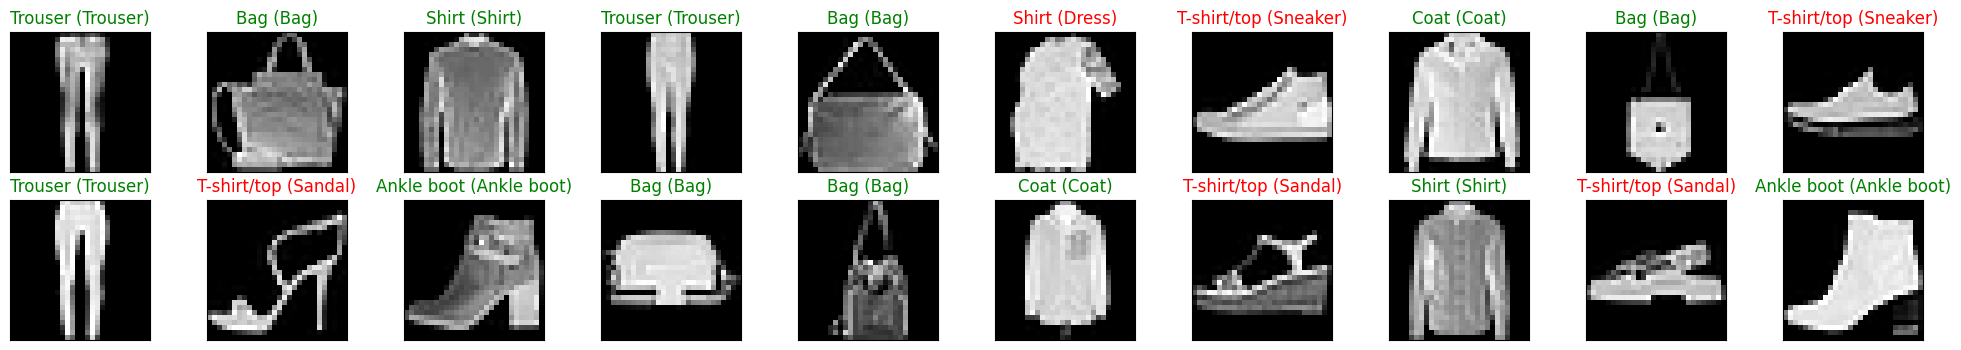

In [15]:
# TODO: Visualize a few test images with predicted and true labels
# - Sample a batch from test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)
# get predictions
preds = np.squeeze(cnn(images).data.max(1, keepdim=True)[1].numpy())
images = images.numpy()
# - Run model and plot images with 'pred vs true' titles
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, batch_size // 2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx] else "red"))

## Task 2: YOLOv8 Pretrained Predictions (No Training)
Use a pretrained YOLOv8 model to run inference on any image of your choice and visualize detections.

**Why this matters:**
- Demonstrates transfer learning and using pretrained models for object detection.
- Learn how to quickly test a detector on real images.

**Steps:**
- Install `ultralytics` if not available.
- Load a YOLOv8 model (e.g., `yolov8n.pt`).
- Run predictions on an image path.
- Visualize the detections (boxes, labels, confidences).

**Hint:** Use `from ultralytics import YOLO`, `YOLO('yolov8n.pt')`, and `model.predict(source=...)`.

In [ ]:
# TODO: Install ultralytics if needed (pip)
# %pip install ultralytics
# - Restart the kernel if required after installation


0: 448x640 1 person, 1 dog, 1 horse, 82.0ms
Speed: 2.0ms preprocess, 82.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


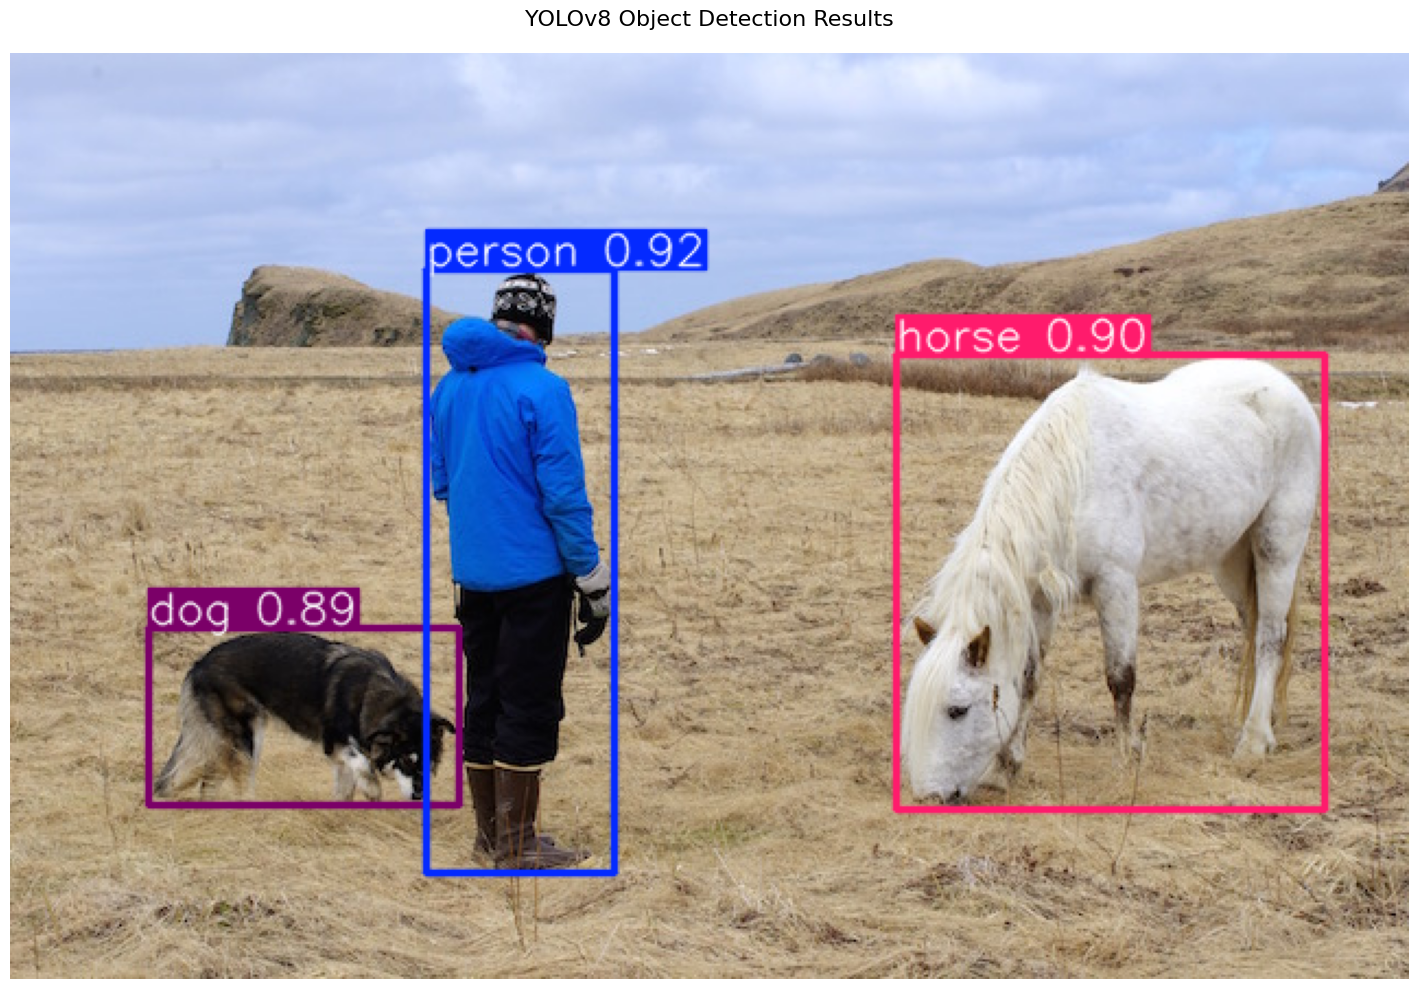

In [17]:
# TODO: Load a pretrained YOLOv8 model and run predictions on an image
# - Visualize results with matplotlib (convert BGR->RGB if using OpenCV)
import cv2
from ultralytics import YOLO
from PIL import Image
model = YOLO('yolov8n.pt')
img= cv2.imread(r'C:\Users\OPT\Downloads\person.jpg')
results = model.predict(source=img)
result = results[0]
plotted_image = result.plot()
plotted_image_rgb = cv2.cvtColor(plotted_image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.imshow(plotted_image_rgb)
plt.axis('off')
plt.title('YOLOv8 Object Detection Results', fontsize=16, pad=20)
plt.tight_layout()
plt.show()    

## Task 3: YOLOv8 Training Example (Small Demo)
Choose any small dataset (e.g., from Roboflow or Kaggle) and train a YOLOv8 model for a few epochs (e.g., 3) as a demonstration. Then run predictions with the trained model.

**Why this matters:**
- Understand the end-to-end YOLO training pipeline.
- See how dataset configuration (classes, paths) connects to training code.

**Steps:**
- Prepare your dataset directory and a `data.yaml` describing train/val paths and class names.
- Train a small model (e.g., `yolov8n.pt`) for ~3 epochs.
- Run predictions on a few sample images.
- Reflect: Are the predictions what you expected? Why or why not?

**Notes:**
- Do NOT upload datasets to GitHub. Keep them locally or use a data hosting service.
- Training for 3 epochs is just for demonstration; try longer training later.
- If you can't use GPU, small images and fewer epochs help.
- If you can't use GPU, you can train your models on Kaggle or Google Colab in the future for free access to GPUs on their servers

In [29]:
# TODO: Provide path to your YOLOv8 data.yaml
# - Ensure train/val image directories and class names are correct
import yaml 
import matplotlib.image as mpimg

train_path = r'C:\Users\OPT\OneDrive\Desktop\sky\archive\VehiclesDetectionDataset\train'
val_path = r'C:\Users\OPT\OneDrive\Desktop\sky\archive\VehiclesDetectionDataset\valid'
test_path = r'C:\Users\OPT\OneDrive\Desktop\sky\archive\VehiclesDetectionDataset\test'

yaml_content = f"""
test: {test_path}
train: {train_path}
val: {val_path}

nc: 5  # Number of classes
names: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']
"""
output_path = 'data.yaml'
with open(output_path, 'w') as file:
    file.write(yaml_content)
color_code = "\033[38;2;163;196;243m" 
reset_code = "\033[0m"
print(f"{color_code}YAML file has been saved to {output_path}{reset_code}")

output_path = 'data.yaml'
with open(output_path, 'r') as file:
    data = yaml.safe_load(file)
class_names = data['names']
print(f"{color_code}Class Names:{reset_code} {class_names}")


YAML file has been saved to data.yaml
Class Names: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']


In [ ]:
# TODO: Train YOLOv8 for a few epochs (e.g., 3)
# - Save the path to best weights (runs/detect/train*/weights/best.pt)
import os
modell = YOLO('yolov8n.pt')
res = modell.train(data=output_path,epochs=3)
runs_dir = "runs/detect"
if os.path.exists(runs_dir):
        train_folders = [f for f in os.listdir(runs_dir) if f.startswith('train')]
        if train_folders:
            latest_train = sorted(train_folders)[-1]
            weights_path = os.path.join(runs_dir, latest_train, 'weights', 'best.pt')
            if os.path.exists(weights_path):
                print(f"Best weights found: {weights_path}")
            else:
                print("Best weights not found in expected location")
        print("Using pretrained yolov8n.pt for demo")
modell = YOLO(weights_path)
print(f"Trained model loaded from: {weights_path}")


Ultralytics 8.3.205  Python-3.13.7 torch-2.8.0+cpu CPU (11th Gen Intel Core i7-1185G7 @ 3.00GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

NameError: name 'weights_path' is not defined

In [ ]:
# TODO: Run predictions with the trained YOLO model and visualize
# - Pick one or more images and display bounding boxes/labels
image_paths = r'C:\Users\OPT\OneDrive\Desktop\sky\archive\VehiclesDetectionDataset\test\images'
num_images = min(4, len(image_paths))
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()
for i, image_path in enumerate(image_paths[:num_images]):
        # Run prediction
        results = modell.predict(source=image_path, conf=confidence, verbose=False)
        result = results[0]
        
        # Get image with bounding boxes
        plotted_image = result.plot()
        plotted_image_rgb = cv2.cvtColor(plotted_image, cv2.COLOR_BGR2RGB)
        
        # Plot
        axes[i].imshow(plotted_image_rgb)
        axes[i].set_title(f'Test Image {i+1}\nDetections: {len(result.boxes) if result.boxes else 0}',fontsize=12)
        axes[i].axis('off')
        if result.boxes is not None and len(result.boxes) > 0:
            print(f"Image {i+1}: {len(result.boxes)} detection(s)")
            for j, box in enumerate(result.boxes):
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                class_name = result.names[class_id]
                print(f"  - {class_name}: {confidence:.3f}")
        else:
            print(f"Image {i+1}: No detections")
plt.suptitle('YOLOv8 Training Demo - Predictions with Trained Model', fontsize=16)
plt.tight_layout()
plt.show()       

### Reflection
- Are the predictions what you expected?
- If performance is weak, why? (data size/quality, epochs, augmentations, etc.)
- What would you adjust for a more serious training run?
- What other arguments can you use for the training function.